# Predicting Trametinib Sensitivity in Cancer Cell Lines

## Introduction

This project investigates whether cancer driver mutation profiles can be used to predict the sensitivity of cancer cell lines to **Trametinib**, a small-molecule inhibitor of MEK1 and MEK2 in the RAS–RAF–MEK–ERK (MAPK) signalling pathway.

Drug-response data from the **Genomics of Drug Sensitivity in Cancer (GDSC)** are integrated with driver mutation data from **Cell Model Passports** using Sanger Model IDs.

The primary objective is to explore relationships between genomic alterations and experimentally measured Trametinib response (`LN_IC50`) and, subsequently, to develop machine learning models that predict drug sensitivity from genomic features.

### Research Question

**Can cancer driver mutation profiles predict cancer cell line sensitivity to Trametinib?**

### Initial Objectives

1. Explore and validate the GDSC drug-response data.
2. Explore the cancer driver mutation data.
3. Identify cancer cell lines with both Trametinib response and mutation data.
4. Investigate the prevalence of mutations in MAPK pathway and related cancer genes.
5. Construct a machine-learning-ready dataset linking genomic features to Trametinib response.

## Notebook Contents

This notebook focuses on the initial exploration and preparation of the project data alongside exploratory data analysis.

The analysis includes:

1. Loading the GDSC drug-response dataset.
2. Inspecting dataset dimensions, variables, and missing values.
3. Exploring the distribution of drug-response measurements.
4. Identifying Trametinib-treated cancer cell lines.
5. Loading and exploring the Cell Model Passports driver mutation dataset.
6. Assessing overlap between Trametinib-treated cell lines and available mutation data.
7. Exploring mutation prevalence in MAPK pathway and related cancer genes.
8. Preparing the data for subsequent feature engineering and machine learning analysis.

No predictive models are trained in this notebook. The purpose is to understand the available data and establish a clean foundation for the next stages of the project.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3

# 1. Dataset Selection

In [5]:
gdsc = pd.read_csv("../data/GDSC2-dataset.csv")
mutations = pd.read_csv("../data/mutations_summary.csv")

The GDSC2 dataset was selected because it provides experimentally measured drug-response values across a large panel of cancer cell lines. The Cell Model Passports mutation dataset was selected because it provides driver mutation annotations linked by Sanger Model ID, enabling genomic and response data to be integrated.

# 2. Dataset Exploration

## 2.1. GDSC Drug Response Data

The GDSC dataset contains experimentally measured responses of cancer cell lines to anti-cancer compounds. Initial exploration is performed to understand the dataset structure, available variables, and data quality.

In [6]:
print("Dataset shape:", gdsc.shape)

gdsc.head()

Dataset shape: (242036, 19)


,DATASET,NLME_RESULT_ID,NLME_CURVE_ID,COSMIC_ID,CELL_LINE_NAME,SANGER_MODEL_ID,TCGA_DESC,DRUG_ID,DRUG_NAME,PUTATIVE_TARGET,PATHWAY_NAME,COMPANY_ID,WEBRELEASE,MIN_CONC,MAX_CONC,LN_IC50,AUC,RMSE,Z_SCORE
0,GDSC2,343,15946310,683667,PFSK-1,SIDM01132,MB,1003,Camptothecin,TOP1,DNA replication,1046,Y,0.0001,0.1,-1.463887,0.930220,0.089052,0.433123
1,GDSC2,343,15946548,684052,A673,SIDM00848,UNCLASSIFIED,1003,Camptothecin,TOP1,DNA replication,1046,Y,0.0001,0.1,-4.869455,0.614970,0.111351,-1.421100
2,GDSC2,343,15946830,684057,ES5,SIDM00263,UNCLASSIFIED,1003,Camptothecin,TOP1,DNA replication,1046,Y,0.0001,0.1,-3.360586,0.791072,0.142855,-0.599569
3,GDSC2,343,15947087,684059,ES7,SIDM00269,UNCLASSIFIED,1003,Camptothecin,TOP1,DNA replication,1046,Y,0.0001,0.1,-5.044940,0.592660,0.135539,-1.516647
4,GDSC2,343,15947369,684062,EW-11,SIDM00203,UNCLASSIFIED,1003,Camptothecin,TOP1,DNA replication,1046,Y,0.0001,0.1,-3.741991,0.734047,0.128059,-0.807232


In [7]:
gdsc.info()

<class 'pandas.DataFrame'>
RangeIndex: 242036 entries, 0 to 242035
Data columns (total 19 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   DATASET          242036 non-null  str    
 1   NLME_RESULT_ID   242036 non-null  int64  
 2   NLME_CURVE_ID    242036 non-null  int64  
 3   COSMIC_ID        242036 non-null  int64  
 4   CELL_LINE_NAME   242036 non-null  str    
 5   SANGER_MODEL_ID  242036 non-null  str    
 6   TCGA_DESC        240969 non-null  str    
 7   DRUG_ID          242036 non-null  int64  
 8   DRUG_NAME        242036 non-null  str    
 9   PUTATIVE_TARGET  214881 non-null  str    
 10  PATHWAY_NAME     242036 non-null  str    
 11  COMPANY_ID       242036 non-null  int64  
 12  WEBRELEASE       242036 non-null  str    
 13  MIN_CONC         242036 non-null  float64
 14  MAX_CONC         242036 non-null  float64
 15  LN_IC50          242036 non-null  float64
 16  AUC              242036 non-null  float64
 17  RM

In [8]:
gdsc.describe()

,NLME_RESULT_ID,NLME_CURVE_ID,COSMIC_ID,DRUG_ID,COMPANY_ID,MIN_CONC,MAX_CONC,LN_IC50,AUC,RMSE,Z_SCORE
count,242036.0,2.420360e+05,2.420360e+05,242036.000000,242036.000000,242036.000000,242036.000000,242036.000000,242036.000000,242036.000000,2.420360e+05
mean,343.0,1.606806e+07,9.921059e+05,1594.042444,1042.966604,0.023143,23.462279,2.817079,0.882592,0.082779,7.312962e-10
std,0.0,7.028749e+04,2.209819e+05,398.740714,16.911327,0.158738,158.622810,2.762229,0.146998,0.042695,9.993925e-01
min,343.0,1.594631e+07,6.836670e+05,1003.000000,1001.000000,0.000010,0.010000,-8.747724,0.006282,0.003274,-8.254501e+00
25%,343.0,1.600719e+07,9.068050e+05,1149.000000,1043.000000,0.003002,3.000000,1.508018,0.849449,0.051107,-6.568485e-01
50%,343.0,1.606807e+07,9.097200e+05,1631.000000,1046.000000,0.010005,10.000000,3.236731,0.944196,0.076083,1.058000e-02
75%,343.0,1.612893e+07,1.240144e+06,1912.000000,1046.000000,0.010005,10.000000,4.700110,0.974934,0.106105,6.560362e-01
max,343.0,1.618978e+07,1.789883e+06,2499.000000,1101.000000,2.001054,2000.000000,13.820189,0.998904,0.299984,7.978776e+00


In [9]:
print("Unique cell lines:", gdsc["SANGER_MODEL_ID"].nunique())
print("Unique drugs:", gdsc["DRUG_NAME"].nunique())
print("Unique cancer types:", gdsc["TCGA_DESC"].nunique())

Unique cell lines: 969
Unique drugs: 286
Unique cancer types: 32


In [10]:
# Assess missing values in variables used for this analysis
columns_of_interest = [
    "SANGER_MODEL_ID",
    "CELL_LINE_NAME",
    "DRUG_NAME",
    "LN_IC50",
    "AUC",
    "Z_SCORE",
    "TCGA_DESC"
]

missing_values = gdsc[columns_of_interest].isnull().sum()

display(missing_values)

print(f"\nTotal missing values: {missing_values.sum()}")

SANGER_MODEL_ID       0
CELL_LINE_NAME        0
DRUG_NAME             0
LN_IC50               0
AUC                   0
Z_SCORE               0
TCGA_DESC          1067
dtype: int64


Total missing values: 1067


Missing values were assessed for the variables used in this study. All key identifiers (SANGER_MODEL_ID and CELL_LINE_NAME) and drug response measurements (LN_IC50, AUC, and Z_SCORE) were complete, with no missing values detected. The only missing values occurred in TCGA_DESC (1,067 records), which provides tumour type annotation. As TCGA_DESC was used only for exploratory analyses and not for constructing the matched dataset or modelling drug response, these missing values were retained and did not affect downstream preprocessing.

In [11]:
print("Duplicate rows:", gdsc.duplicated().sum())

Duplicate rows: 0


In [12]:
# Summarise drug coverage and the distribution of LN_IC50 values for each drug
# The drugs are grouped by name, putative target, and pathway, then ranked by the number of unique cell lines tested.

drug_summary = (
    gdsc.groupby(["DRUG_NAME", "PUTATIVE_TARGET", "PATHWAY_NAME"], dropna=False)
        .agg(
            n_cell_lines=("SANGER_MODEL_ID", "nunique"),
            mean_ln_ic50=("LN_IC50", "mean"),
            std_ln_ic50=("LN_IC50", "std"),
            min_ln_ic50=("LN_IC50", "min"),
            max_ln_ic50=("LN_IC50", "max")
        )
        .assign(
            range_ln_ic50=lambda x: x["max_ln_ic50"] - x["min_ln_ic50"]
        )
        .sort_values("n_cell_lines", ascending=False)
)

drug_summary.head(30)

,,,n_cell_lines,mean_ln_ic50,std_ln_ic50,min_ln_ic50,max_ln_ic50,range_ln_ic50
DRUG_NAME,PUTATIVE_TARGET,PATHWAY_NAME,,,,,,
MG-132,"Proteasome, CAPN1",Protein stability and degradation,969,-1.283393,0.722336,-3.171575,4.479962,7.651537
Nutlin-3a (-),MDM2,p53 pathway,968,4.416219,1.787005,-0.867722,9.340026,10.207748
Docetaxel,Microtubule stabiliser,Mitosis,968,-3.415391,2.548620,-7.308140,5.631903,12.940043
MK-2206,"AKT1, AKT2",PI3K/MTOR signaling,968,2.724173,1.486104,-2.560495,7.282918,9.843413
Palbociclib,"CDK4, CDK6",Cell cycle,968,3.440316,1.570024,-2.212706,8.871291,11.083997
Camptothecin,TOP1,DNA replication,968,-2.259385,1.836654,-5.881366,3.692250,9.573616
PD0325901,"MEK1, MEK2",ERK MAPK signaling,968,1.342255,2.143469,-7.185140,6.482915,13.668055
Staurosporine,Broad spectrum kinase inhibitor,RTK signaling,968,-2.793135,1.384601,-6.925405,3.462082,10.387487
5-Fluorouracil,Antimetabolite (DNA & RNA),Other,968,4.386510,1.715815,-0.868020,10.174480,11.042500


In [13]:
high_coverage_drugs = drug_summary[
    drug_summary["n_cell_lines"] >= 900
].sort_values("std_ln_ic50", ascending=False)

high_coverage_drugs.head(20)

,,,n_cell_lines,mean_ln_ic50,std_ln_ic50,min_ln_ic50,max_ln_ic50,range_ln_ic50
DRUG_NAME,PUTATIVE_TARGET,PATHWAY_NAME,,,,,,
Gemcitabine,Pyrimidine antimetabolite,DNA replication,960,-0.765812,3.009416,-6.551753,7.716931,14.268684
Docetaxel,Microtubule stabiliser,Mitosis,968,-3.415391,2.548620,-7.308140,5.631903,12.940043
BI-2536,"PLK1, PLK2, PLK3",Cell cycle,923,-1.154665,2.434221,-6.258933,5.562181,11.821114
Dasatinib,"ABL, SRC, Ephrins, PDGFR, KIT","Other, kinases",962,1.285622,2.320329,-8.642551,6.898136,15.540687
Alisertib,AURKA,Mitosis,949,1.590190,2.287407,-4.351967,6.418005,10.769972
Trametinib,"MEK1, MEK2",ERK MAPK signaling,966,0.216468,2.255970,-8.554725,6.719050,15.273775
Talazoparib,"PARP1, PARP2",Genome integrity,956,2.767533,2.211696,-4.824148,8.103714,12.927862
Pevonedistat,NAE,Other,956,0.873530,2.145611,-4.343407,8.677827,13.021234
PD0325901,"MEK1, MEK2",ERK MAPK signaling,968,1.342255,2.143469,-7.185140,6.482915,13.668055


Drug response measurements were summarised for each drug, together with its annotated putative target and pathway. For each drug, the number of unique cell lines tested was calculated alongside the mean, standard deviation, minimum, maximum, and range of LN_IC50 values.

The table was sorted by the number of tested cell lines to identify drugs with the broadest experimental coverage. Drugs with both high cell-line coverage and a wide range of LN_IC50 values are particularly suitable for downstream analysis because they provide a larger sample size and greater variation in drug response.

## 2.2. Selection and Initial Exploration of Trametinib

### Selection of Trametinib

Trametinib was selected for further analysis based on a combination of broad cell-line coverage, substantial variability in drug response, and biological interpretability.

In [14]:
# Filter the GDSC dataset to Trametinib-treated cell lines
trametinib = gdsc[gdsc["DRUG_NAME"] == "Trametinib"].copy()

print("Trametinib dataset shape:", trametinib.shape)
print("Unique Trametinib-treated cell lines:", trametinib["SANGER_MODEL_ID"].nunique())

trametinib.head()

Trametinib dataset shape: (966, 19)
Unique Trametinib-treated cell lines: 966


,DATASET,NLME_RESULT_ID,NLME_CURVE_ID,COSMIC_ID,CELL_LINE_NAME,SANGER_MODEL_ID,TCGA_DESC,DRUG_ID,DRUG_NAME,PUTATIVE_TARGET,PATHWAY_NAME,COMPANY_ID,WEBRELEASE,MIN_CONC,MAX_CONC,LN_IC50,AUC,RMSE,Z_SCORE
76448,GDSC2,343,15946367,683667,PFSK-1,SIDM01132,MB,1372,Trametinib,"MEK1, MEK2",ERK MAPK signaling,1046,Y,0.001001,1.0,2.272281,0.975755,0.116230,0.911277
76449,GDSC2,343,15946628,684052,A673,SIDM00848,UNCLASSIFIED,1372,Trametinib,"MEK1, MEK2",ERK MAPK signaling,1046,Y,0.001001,1.0,1.221512,0.950128,0.149938,0.445504
76450,GDSC2,343,15946915,684057,ES5,SIDM00263,UNCLASSIFIED,1372,Trametinib,"MEK1, MEK2",ERK MAPK signaling,1046,Y,0.001001,1.0,2.590889,0.982881,0.075531,1.052506
76451,GDSC2,343,15947167,684059,ES7,SIDM00269,UNCLASSIFIED,1372,Trametinib,"MEK1, MEK2",ERK MAPK signaling,1046,Y,0.001001,1.0,2.889071,0.986998,0.080227,1.184680
76452,GDSC2,343,15947449,684062,EW-11,SIDM00203,UNCLASSIFIED,1372,Trametinib,"MEK1, MEK2",ERK MAPK signaling,1046,Y,0.001001,1.0,3.061922,0.978852,0.098135,1.261300


In [15]:
print(
    "Duplicate Sanger Model IDs:",
    trametinib["SANGER_MODEL_ID"].duplicated().sum()
)

Duplicate Sanger Model IDs: 0


Trametinib was selected for this study because it combines broad experimental coverage (966 cancer cell lines), substantial variation in drug response, and a well-defined mechanism of action. As a MEK1/2 inhibitor targeting the MAPK signalling pathway, it provides an ideal model for investigating whether recurrent driver mutations can explain differences in drug sensitivity.

### Missing Values in the Trametinib Subset

Only 6 Trametinib-treated cell lines have missing `TCGA_DESC` values. All other variables, including the primary response variable `LN_IC50`, are complete.

The small number of missing cancer-type annotations is unlikely to substantially affect the overall analysis. These records can be retained if cancer type is not used as a model feature, or handled during preprocessing if `TCGA_DESC` is included in the final feature set.

In [16]:
# Check missing values in the Trametinib subset
trametinib.isnull().sum().sort_values(ascending=False)

TCGA_DESC          6
DATASET            0
PATHWAY_NAME       0
RMSE               0
AUC                0
LN_IC50            0
MAX_CONC           0
MIN_CONC           0
WEBRELEASE         0
COMPANY_ID         0
PUTATIVE_TARGET    0
NLME_RESULT_ID     0
DRUG_NAME          0
DRUG_ID            0
SANGER_MODEL_ID    0
CELL_LINE_NAME     0
COSMIC_ID          0
NLME_CURVE_ID      0
Z_SCORE            0
dtype: int64

In [17]:
# Summarise Trametinib response measurements
trametinib[["LN_IC50", "AUC", "Z_SCORE", "RMSE"]].describe()

,LN_IC50,AUC,Z_SCORE,RMSE
count,966.000000,966.000000,9.660000e+02,966.000000
mean,0.216468,0.829534,7.246377e-09,0.131708
std,2.255970,0.188362,1.000000e+00,0.048157
min,-8.554725,0.010009,-3.887992e+00,0.020375
25%,-0.942016,0.775142,-5.135193e-01,0.097743
50%,0.540893,0.896712,1.438080e-01,0.125228
75%,1.855009,0.963518,7.263127e-01,0.160960
max,6.719050,0.996620,2.882388e+00,0.289646


Descriptive statistics were calculated for the Trametinib response variables. LN_IC50 was selected as the primary outcome for subsequent analyses because it quantifies drug sensitivity and exhibited substantial variability across the 966 screened cancer cell lines. The distribution of LN_IC50 is explored further below.

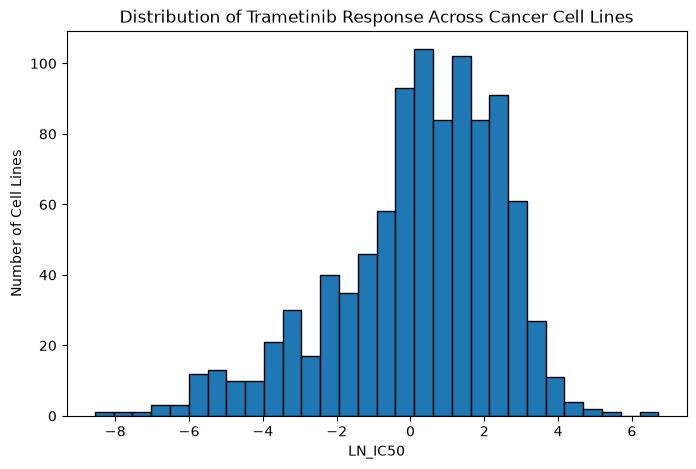

In [18]:
plt.figure(figsize=(8, 5))
plt.hist(trametinib["LN_IC50"], bins=30, edgecolor="black")
plt.xlabel("LN_IC50")
plt.ylabel("Number of Cell Lines")
plt.title("Distribution of Trametinib Response Across Cancer Cell Lines")
plt.show()

LN_IC50 values showed substantial variation across Trametinib-treated cell lines, indicating heterogeneous drug sensitivity. This variability makes LN_IC50 a suitable continuous response variable for subsequent regression analyses.

## 2.3. Driver Mutation Dataset

The Cell Model Passports mutation dataset contains genomic alterations identified across cancer cell line models. This dataset will provide the genomic features used to investigate and subsequently predict Trametinib response.

Initial exploration was performed to assess the structure of the dataset, data quality, number of cancer models represented, and prevalence of mutations in genes potentially relevant to Trametinib sensitivity.

In [19]:
print("Dataset shape:", mutations.shape)

mutations.head()

Dataset shape: (13699, 19)


,gene_symbol,ensembl_gene_id,transcript_id,model_name,model_id,protein_mutation,rna_mutation,cdna_mutation,chromosome,position,reference,alternative,cancer_driver,cancer_predisposition_variant,effect,vaf,coding,source,gene_id
0,CASP8,ENSG00000064012,CCDS42798,GR-ST,SIDM01259,p.F338fs*11,r.1207delU,c.1011delT,chr2,201284846.0,AT,A,t,f,frameshift,0.4921,t,Sanger,SIDG03513
1,BMPR2,ENSG00000204217,CCDS33361,GR-ST,SIDM01259,p.N343fs*14,r.2172delA,c.1024delA,chr2,202530849.0,GA,G,t,f,frameshift,0.5156,t,Sanger,SIDG02364
2,MCM3AP,ENSG00000160294,CCDS13734,GR-ST,SIDM01259,p.?,r.5363+1delg,c.5038+1delg,chr21,46244805.0,AC,A,t,f,ess_splice,0.5227,t,Sanger,SIDG17421
3,DGCR8,ENSG00000128191,CCDS13773,GR-ST,SIDM01259,p.P727fs*18,r.2595_2596insa,c.2175_2176insA,chr22,20108940.0,C,CA,t,f,frameshift,0.4931,t,Sanger,SIDG06490
4,MB21D2,ENSG00000180611,CCDS3302,GR-ST,SIDM01259,p.N216fs*11,r.663delA,c.647delA,chr3,192799214.0,AT,A,t,f,frameshift,0.5747,t,Sanger,SIDG17353


In [20]:
mutations.info()

<class 'pandas.DataFrame'>
RangeIndex: 13699 entries, 0 to 13698
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   gene_symbol                    13699 non-null  str    
 1   ensembl_gene_id                13699 non-null  str    
 2   transcript_id                  13301 non-null  str    
 3   model_name                     13699 non-null  str    
 4   model_id                       13699 non-null  str    
 5   protein_mutation               13699 non-null  str    
 6   rna_mutation                   13699 non-null  str    
 7   cdna_mutation                  13699 non-null  str    
 8   chromosome                     13301 non-null  str    
 9   position                       13301 non-null  float64
 10  reference                      13301 non-null  str    
 11  alternative                    13301 non-null  str    
 12  cancer_driver                  13699 non-null  str    
 1

In [21]:
mutations.isnull().sum().sort_values(ascending=False)

position                         398
alternative                      398
transcript_id                    398
chromosome                       398
reference                        398
source                             0
coding                             0
vaf                                0
effect                             0
cancer_predisposition_variant      0
cancer_driver                      0
gene_symbol                        0
ensembl_gene_id                    0
cdna_mutation                      0
rna_mutation                       0
protein_mutation                   0
model_id                           0
model_name                         0
gene_id                            0
dtype: int64

In [22]:
print("Duplicate rows:", mutations.duplicated().sum())

Duplicate rows: 0


In [23]:
print("Unique models:", mutations["model_id"].nunique())
print("Unique genes:", mutations["gene_symbol"].nunique())

mutations[
    ["model_id", "model_name", "gene_symbol", "cancer_driver", 
     "cancer_predisposition_variant", "effect", "protein_mutation"]
].head(10)

Unique models: 1533
Unique genes: 613


,model_id,model_name,gene_symbol,cancer_driver,cancer_predisposition_variant,effect,protein_mutation
0,SIDM01259,GR-ST,CASP8,t,f,frameshift,p.F338fs*11
1,SIDM01259,GR-ST,BMPR2,t,f,frameshift,p.N343fs*14
2,SIDM01259,GR-ST,MCM3AP,t,f,ess_splice,p.?
3,SIDM01259,GR-ST,DGCR8,t,f,frameshift,p.P727fs*18
4,SIDM01259,GR-ST,MB21D2,t,f,frameshift,p.N216fs*11
5,SIDM01259,GR-ST,TET2,t,f,frameshift,p.L615fs*24
6,SIDM01259,GR-ST,SDHA,t,f,frameshift,p.L649fs*4
7,SIDM01259,GR-ST,DAXX,t,f,frameshift,p.R306fs*38
8,SIDM01259,GR-ST,IKZF1,t,f,frameshift,p.R105fs*4
9,SIDM01259,GR-ST,KMT2C,t,f,frameshift,p.A3825fs*21


Each row represents a mutation record associated with a particular cancer cell line. A cell line can appear multiple times because it may contain mutations in multiple genes, or more than one mutation record within the same gene. Individual cell lines can therefore appear multiple times, reflecting mutations in different genes. The model_id field provides the identifier used to link genomic data to the GDSC drug-response dataset, while gene_symbol identifies the affected gene. For machine learning, these data will subsequently need to be transformed from long format into a feature matrix containing one row per cell line and genomic features as columns.

# 3. Data Preprocessing

## 3.1. Identify Overlapping Cell Lines

### Overlap Between Trametinib Response and Mutation Data

In [24]:
# Identify Trametinib-treated cell lines
trametinib_models = set(trametinib["SANGER_MODEL_ID"])

# Identify cell lines represented in the mutation dataset
mutation_models = set(mutations["model_id"])

# Find models present in both datasets
overlapping_models = trametinib_models.intersection(mutation_models)

print("Trametinib-treated cell lines:", len(trametinib_models))
print("Cell lines with mutation data:", len(mutation_models))
print("Overlapping cell lines:", len(overlapping_models))
print(
    "Percentage of Trametinib-treated cell lines with mutation data:",
    round(len(overlapping_models) / len(trametinib_models) * 100, 1),
    "%"
)

Trametinib-treated cell lines: 966
Cell lines with mutation data: 1533
Overlapping cell lines: 948
Percentage of Trametinib-treated cell lines with mutation data: 98.1 %


Of the 966 cancer cell lines with Trametinib response measurements, 948 (98.1%) are also represented in the driver mutation dataset. This high level of overlap indicates that genomic features can be linked to drug-response measurements for almost the entire Trametinib cohort, providing a strong foundation for subsequent feature engineering and machine learning analysis. The remaining 18 cell lines without matched mutation data will be excluded from analyses requiring genomic features.

## 3.2. Create the matched mutation cohort

In [25]:
# Filter mutation data to cell lines with Trametinib response data
# Retain mutation records only for cell lines with available Trametinib response data
trametinib_mutations = mutations[
    mutations["model_id"].isin(overlapping_models)
].copy()

print("Mutation records in matched cohort:", trametinib_mutations.shape[0])
print("Unique matched cell lines:", trametinib_mutations["model_id"].nunique())
print("Unique mutated genes:", trametinib_mutations["gene_symbol"].nunique())

Mutation records in matched cohort: 8522
Unique matched cell lines: 948
Unique mutated genes: 597


## 3.3. Create the Matched Trametinib Response Cohort

In [26]:
trametinib_matched = trametinib[
    trametinib["SANGER_MODEL_ID"].isin(overlapping_models)
].copy()

print(
    "Matched Trametinib response rows:",
    trametinib_matched.shape[0]
)
print(
    "Matched Trametinib cell lines:",
    trametinib_matched["SANGER_MODEL_ID"].nunique()
)

Matched Trametinib response rows: 948
Matched Trametinib cell lines: 948


## 3.4. Merge drug response and mutation data

### Merging Drug Response and Mutation Data

Drug response measurements and driver mutation data were merged using the shared Sanger Model ID. The resulting dataset links experimentally measured Trametinib response with the genomic profile of each cancer cell line. Initially, the merged dataset remains in long format, with each row representing a single mutation associated with a specific cell line.

In [27]:
conn = sqlite3.connect("trametinib.db")

trametinib_matched.to_sql(
    "trametinib_matched",
    conn,
    if_exists="replace",
    index=False
)

trametinib_mutations.to_sql(
    "trametinib_mutations",
    conn,
    if_exists="replace",
    index=False
)

8522

In [28]:
query = """
SELECT
    t.SANGER_MODEL_ID,
    t.CELL_LINE_NAME,
    t.TCGA_DESC,
    t.LN_IC50,
    t.AUC,
    t.Z_SCORE,
    m.gene_symbol,
    m.effect,
    m.protein_mutation,
    m.cdna_mutation,
    m.chromosome,
    m.position,
    m.reference,
    m.alternative,
    m.cancer_driver
FROM trametinib_matched AS t
INNER JOIN trametinib_mutations AS m
    ON t.SANGER_MODEL_ID = m.model_id
"""

merged = pd.read_sql_query(query, conn)

# Close the SQLite connection
conn.close()

## 3.5. Validate the merged dataset

In [29]:
print("Merged dataset shape:", merged.shape)
print("Unique matched cell lines:", merged["SANGER_MODEL_ID"].nunique())
print("Unique mutated genes:", merged["gene_symbol"].nunique())
print("Missing gene symbols:", merged["gene_symbol"].isna().sum())
print("Duplicate merged rows:", merged.duplicated().sum())

Merged dataset shape: (8522, 15)
Unique matched cell lines: 948
Unique mutated genes: 597
Missing gene symbols: 0
Duplicate merged rows: 0


The final merged dataset contained 8,522 mutation records across 948 Trametinib-treated cancer cell lines and 597 unique driver genes. No mutation records had missing gene symbols, and no fully duplicated rows were detected. Genomic-level mutation fields were retained because some distinct DNA variants produced the same protein-level consequence and would otherwise appear duplicated after merging.

# 4. Exploratory Data Analysis

In [30]:
mutation_counts = (
    merged.groupby("SANGER_MODEL_ID")["gene_symbol"]
    .count()
    .sort_values(ascending=False)
)

mutation_counts.head()

SANGER_MODEL_ID
SIDM00217    147
SIDM00282    139
SIDM01045    106
SIDM00193    103
SIDM00333     80
Name: gene_symbol, dtype: int64

## 4.1. Outlier Identification

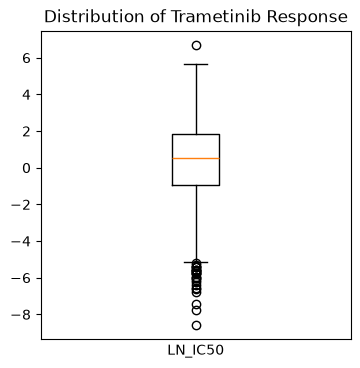

In [31]:
plt.figure(figsize=(4, 4))

plt.boxplot(trametinib["LN_IC50"], orientation="vertical")

plt.xlabel("LN_IC50")
plt.xticks([])          # Removes the "1"
plt.title("Distribution of Trametinib Response")

plt.show()

The boxplot demonstrates considerable variation in LN_IC50 values across Trametinib-treated cell lines, with several potential outliers at both extremes of the distribution. As these values are consistent with expected biological heterogeneity in drug sensitivity, no outliers were removed prior to downstream analyses.

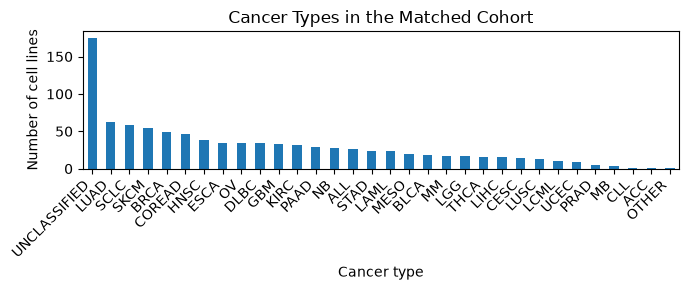

In [32]:
cancer_counts = (
    trametinib_matched["TCGA_DESC"]
    .value_counts()
)

plt.figure(figsize=(7,3))
cancer_counts.plot(kind="bar")

plt.xlabel("Cancer type")
plt.ylabel("Number of cell lines")
plt.title("Cancer Types in the Matched Cohort")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

The matched cohort represents a wide range of tumour types. While a substantial proportion of cell lines are classified as UNCLASSIFIED, the remaining cell lines span numerous cancer types, including lung adenocarcinoma (LUAD), small cell lung cancer (SCLC), skin cutaneous melanoma (SKCM), breast cancer (BRCA) and colorectal adenocarcinoma (COREAD). This diversity provides a broad biological context for investigating genomic predictors of Trametinib response.

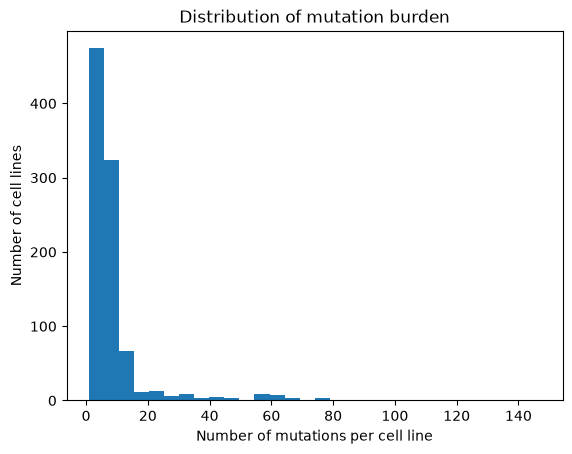

In [33]:
plt.hist(mutation_counts, bins=30)
plt.xlabel("Number of mutations per cell line")
plt.ylabel("Number of cell lines")
plt.title("Distribution of mutation burden")
plt.show()

### Driver Mutation Prevalence in the Matched Cohort

The 948 cancer cell lines with both Trametinib response and driver mutation data contained 8,522 mutation records across 597 genes. TP53 was the most frequently mutated gene, with mutations present in 643 cell lines. Several genes with direct relevance to MAPK signalling were also among the most frequently mutated, including KRAS (125 cell lines) and BRAF (82 cell lines). This supports further investigation of MAPK pathway alterations as potential genomic features associated with Trametinib response.

In [34]:
# Count the number of cell lines with a mutation in each gene
mutation_prevalence = (
    trametinib_mutations
    .groupby("gene_symbol")["model_id"]
    .nunique()
    .sort_values(ascending=False)
)

mutation_prevalence.head(20)

gene_symbol
TP53       643
KRAS       125
KMT2C      124
PTEN       106
KMT2D      104
RB1         97
PIK3CA      93
EP300       87
HLA-A       84
ARID1A      84
BRAF        82
SDHA        78
CDKN2A      76
LRP1B       71
POLQ        69
CREBBP      66
HLA-B       64
SMARCA4     63
CBLC        63
FAT3        63
Name: model_id, dtype: int64

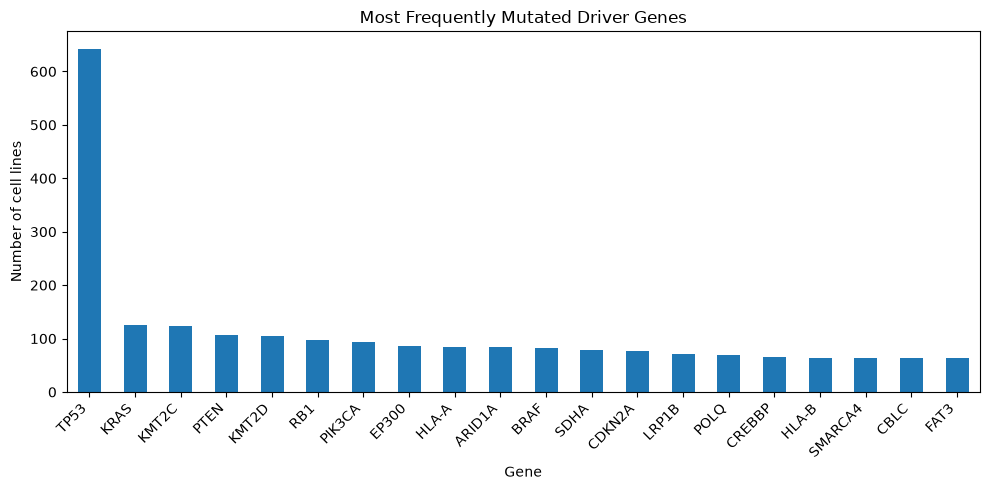

In [35]:
plt.figure(figsize=(10,5))

mutation_prevalence.head(20).plot(kind="bar")

plt.ylabel("Number of cell lines")
plt.xlabel("Gene")
plt.title("Most Frequently Mutated Driver Genes")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

TP53 was the most frequently mutated gene in the matched cohort, followed by KRAS, BRAF, PTEN and PIK3CA. Many of the most common alterations occur in well-established cancer driver genes involved in cell-cycle regulation and signalling pathways. Notably, several genes within the MAPK pathway, including KRAS, BRAF and NRAS, were well represented, supporting further investigation of their relationship with Trametinib sensitivity.

In [61]:
# MAPK-pathway genes used for this analysis

mapk_genes = {
    # RAS family and regulators
    "KRAS", "NRAS", "HRAS",
    "NF1", "RASA1", "RASA2", "RASA3", "RASA4",

    # RAF proteins
    "BRAF", "RAF1", "ARAF",

    # MEK proteins
    "MAP2K1", "MAP2K2",

    # ERK proteins
    "MAPK1", "MAPK3",

    # Receptor tyrosine kinases
    "EGFR", "ERBB2", "ERBB3", "ERBB4",
    "FGFR1", "FGFR2", "FGFR3", "FGFR4",
    "MET", "KIT", "PDGFRA", "PDGFRB",
    "ALK", "RET", "ROS1",

    # Upstream signalling proteins
    "SOS1", "SOS2", "GRB2", "SHC1",

    # MAPK phosphatases and feedback regulators
    "DUSP4", "DUSP5", "DUSP6",
    "SPRY1", "SPRY2", "SPRY4",

    # Other MAPK pathway members
    "MAP3K1", "MAP3K2", "MAP3K3", "MAP3K4",
    "MAP3K5", "MAP3K7", "MAP3K8",
    "MAP2K3", "MAP2K4", "MAP2K5", "MAP2K6", "MAP2K7",
    "MAPK7", "MAPK8", "MAPK9", "MAPK10",
    "MAPK11", "MAPK12", "MAPK13", "MAPK14"
}

print("Number of genes in MAPK gene set:", len(mapk_genes))

Number of genes in MAPK gene set: 60


In [62]:
# Keep only the columns required for this analysis

mapk_data = merged[
    ["SANGER_MODEL_ID", "gene_symbol", "LN_IC50"]
].copy()

display(mapk_data.head())
print("Initial shape:", mapk_data.shape)

,SANGER_MODEL_ID,gene_symbol,LN_IC50
0,SIDM01132,GMPS,2.272281
1,SIDM01132,TP53,2.272281
2,SIDM00848,BRAF,1.221512
3,SIDM00848,TP53,1.221512
4,SIDM00263,FBN2,2.590889


Initial shape: (8522, 3)


In [63]:
# Standardise gene symbols so they match the MAPK gene set

mapk_data["gene_symbol"] = (
    mapk_data["gene_symbol"]
    .astype("string")
    .str.strip()
    .str.upper()
)

display(mapk_data.head())

,SANGER_MODEL_ID,gene_symbol,LN_IC50
0,SIDM01132,GMPS,2.272281
1,SIDM01132,TP53,2.272281
2,SIDM00848,BRAF,1.221512
3,SIDM00848,TP53,1.221512
4,SIDM00263,FBN2,2.590889


In [64]:
# Convert LN_IC50 to a numeric column

mapk_data["LN_IC50"] = pd.to_numeric(
    mapk_data["LN_IC50"],
    errors="coerce"
)

# Remove rows missing information needed for the analysis

mapk_data = mapk_data.dropna(
    subset=["SANGER_MODEL_ID", "gene_symbol", "LN_IC50"]
)

print("Shape after removing missing values:", mapk_data.shape)
print("\nMissing values remaining:")
print(
    mapk_data[
        ["SANGER_MODEL_ID", "gene_symbol", "LN_IC50"]
    ].isna().sum()
)

Shape after removing missing values: (8522, 3)

Missing values remaining:
SANGER_MODEL_ID    0
gene_symbol        0
LN_IC50            0
dtype: int64


In [65]:
# A gene may appear more than once for the same cell line.
# For mutation burden, each mutated gene should count only once per cell line.

rows_before = len(mapk_data)

mapk_data = mapk_data.drop_duplicates(
    subset=["SANGER_MODEL_ID", "gene_symbol"]
)

rows_after = len(mapk_data)

print("Rows before removing duplicates:", rows_before)
print("Rows after removing duplicates:", rows_after)
print("Duplicate rows removed:", rows_before - rows_after)

Rows before removing duplicates: 8522
Rows after removing duplicates: 7835
Duplicate rows removed: 687


In [66]:
# True means the mutated gene belongs to the defined MAPK gene set

mapk_data["is_MAPK_mutation"] = (
    mapk_data["gene_symbol"].isin(mapk_genes)
)

display(mapk_data.head())

,SANGER_MODEL_ID,gene_symbol,LN_IC50,is_MAPK_mutation
0,SIDM01132,GMPS,2.272281,False
1,SIDM01132,TP53,2.272281,False
2,SIDM00848,BRAF,1.221512,True
3,SIDM00848,TP53,1.221512,False
4,SIDM00263,FBN2,2.590889,False


In [67]:
print(mapk_data["is_MAPK_mutation"].value_counts())

is_MAPK_mutation
False    7285
True      550
Name: count, dtype: int64


In [68]:
# Show which MAPK genes are actually present in the matched dataset

mapk_gene_frequencies = (
    mapk_data.loc[
        mapk_data["is_MAPK_mutation"],
        "gene_symbol"
    ]
    .value_counts()
)

display(mapk_gene_frequencies)

gene_symbol
KRAS      125
BRAF       82
NRAS       59
NF1        56
EGFR       21
RASA1      17
ERBB2      16
MAP2K4     15
MAP2K1     14
ERBB4      14
ALK        12
MAP2K7     12
RASA2      12
MET        11
ERBB3      10
FGFR4      10
HRAS        8
FGFR2       8
MAP3K1      8
RET         7
FGFR3       7
SOS1        7
KIT         6
PDGFRA      5
RAF1        4
FGFR1       2
PDGFRB      1
MAP2K2      1
Name: count, dtype: Int64

In [69]:
# Count the number of unique mutated MAPK genes in each cell line

mapk_mutation_counts = (
    mapk_data
    .groupby("SANGER_MODEL_ID")["is_MAPK_mutation"]
    .sum()
    .rename("MAPK_mutation_count")
)

display(mapk_mutation_counts.head())

SANGER_MODEL_ID
SIDM00003    2
SIDM00023    0
SIDM00040    0
SIDM00042    1
SIDM00043    0
Name: MAPK_mutation_count, dtype: int64

In [70]:
# Obtain one Trametinib response value per cell line

cell_line_ic50 = (
    mapk_data
    .groupby("SANGER_MODEL_ID")["LN_IC50"]
    .median()
    .rename("LN_IC50")
)

display(cell_line_ic50.head())

SANGER_MODEL_ID
SIDM00003   -6.416117
SIDM00023    0.550402
SIDM00040   -0.228455
SIDM00042   -1.140312
SIDM00043   -0.671703
Name: LN_IC50, dtype: float64

In [71]:
# Create the final analysis table:
# one row per unique cell-line model

cell_line_mapk = pd.concat(
    [mapk_mutation_counts, cell_line_ic50],
    axis=1
).reset_index()

display(cell_line_mapk.head())

print(
    "Number of unique cell lines:",
    cell_line_mapk["SANGER_MODEL_ID"].nunique()
)

print("Shape of analysis table:", cell_line_mapk.shape)

,SANGER_MODEL_ID,MAPK_mutation_count,LN_IC50
0,SIDM00003,2,-6.416117
1,SIDM00023,0,0.550402
2,SIDM00040,0,-0.228455
3,SIDM00042,1,-1.140312
4,SIDM00043,0,-0.671703


Number of unique cell lines: 948
Shape of analysis table: (948, 3)


In [72]:
# Confirm that there is exactly one row per cell line

print(
    "Duplicate cell-line IDs:",
    cell_line_mapk["SANGER_MODEL_ID"].duplicated().sum()
)

print("\nMissing values:")
print(cell_line_mapk.isna().sum())

print("\nMAPK mutation count summary:")
display(cell_line_mapk["MAPK_mutation_count"].describe())

Duplicate cell-line IDs: 0

Missing values:
SANGER_MODEL_ID        0
MAPK_mutation_count    0
LN_IC50                0
dtype: int64

MAPK mutation count summary:


count    948.000000
mean       0.580169
std        0.803180
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        6.000000
Name: MAPK_mutation_count, dtype: float64

In [73]:
# Number of cell lines in each MAPK mutation-count group

mapk_count_distribution = (
    cell_line_mapk["MAPK_mutation_count"]
    .value_counts()
    .sort_index()
)

print(mapk_count_distribution)

MAPK_mutation_count
0    527
1    330
2     69
3     12
4      5
5      4
6      1
Name: count, dtype: int64


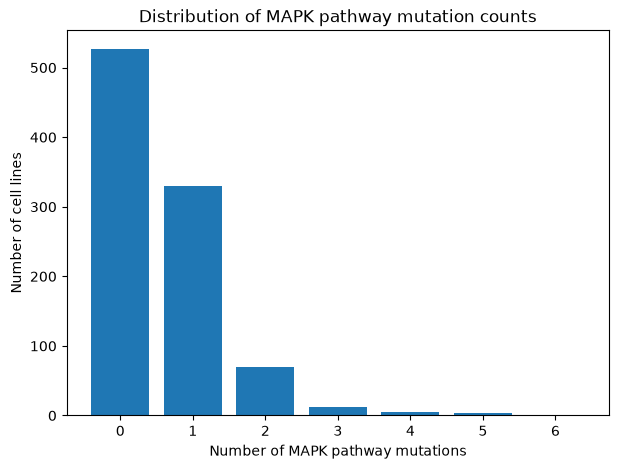

In [74]:
counts = (
    cell_line_mapk["MAPK_mutation_count"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(7,5))
plt.bar(counts.index.astype(str), counts.values)

plt.xlabel("Number of MAPK pathway mutations")
plt.ylabel("Number of cell lines")
plt.title("Distribution of MAPK pathway mutation counts")

plt.show()

In [75]:
from scipy.stats import pearsonr, spearmanr
# Pearson: tests for a linear relationship
pearson_r, pearson_p = pearsonr(
    cell_line_mapk["MAPK_mutation_count"],
    cell_line_mapk["LN_IC50"]
)

# Spearman: tests whether the variables generally increase/decrease together
# without requiring a linear relationship
spearman_r, spearman_p = spearmanr(
    cell_line_mapk["MAPK_mutation_count"],
    cell_line_mapk["LN_IC50"]
)


print("Pearson correlation")
print(f"r = {pearson_r:.3f}")
print(f"p = {pearson_p:.4g}")

print("\nSpearman correlation")
print(f"rho = {spearman_r:.3f}")
print(f"p = {spearman_p:.4g}")

Pearson correlation
r = -0.306
p = 5.332e-22

Spearman correlation
rho = -0.375
p = 5.461e-33


Text(0, 0.5, 'Trametinib LN_IC50 (lower = greater sensitivity)')

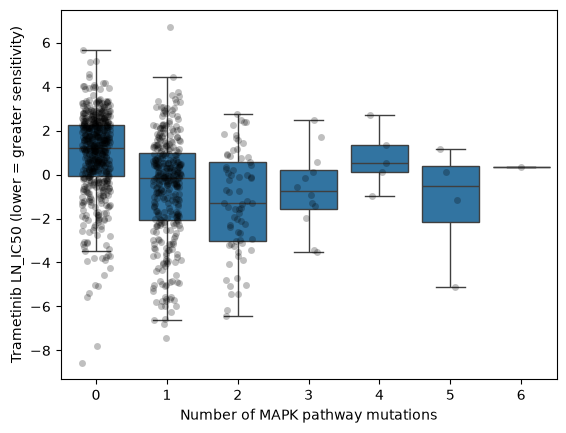

In [76]:
import seaborn as sns

sns.boxplot(
    data=cell_line_mapk,
    x="MAPK_mutation_count",
    y="LN_IC50",
    showfliers=False
)

sns.stripplot(
    data=cell_line_mapk,
    x="MAPK_mutation_count",
    y="LN_IC50",
    color="black",
    alpha=0.25,
    jitter=0.2
)

plt.xlabel("Number of MAPK pathway mutations")
plt.ylabel("Trametinib LN_IC50 (lower = greater sensitivity)")

### MAPK Pathway Driver Mutations

Because Trametinib targets MEK1/2 within the MAPK signalling pathway, mutations affecting genes in this pathway are of particular biological interest. Within the matched cohort, KRAS mutations were present in 125 cell lines, followed by BRAF (82), NRAS (59) and NF1 (56). These observations demonstrate that alterations affecting the MAPK pathway are sufficiently represented to support subsequent analyses investigating their relationship with Trametinib sensitivity.

Although MAPK pathway genes are of particular mechanistic interest because of Trametinib's mode of action, the mutation dataset contains alterations across 597 cancer-associated genes. Subsequent machine learning analyses will therefore consider the broader genomic landscape rather than restricting the analysis to MAPK genes alone.

In [36]:
# Define MAPK pathway and related genes of interest
mapk_genes = [
    "KRAS",
    "NRAS",
    "HRAS",
    "BRAF",
    "RAF1",
    "NF1",
    "MAP2K1",
    "MAP2K2"
]

# Extract prevalence for MAPK-related genes
mapk_prevalence = (
    mutation_prevalence
    .reindex(mapk_genes)
    .fillna(0)
    .astype(int)
    .sort_values(ascending=False)
)

mapk_prevalence

gene_symbol
KRAS      125
BRAF       82
NRAS       59
NF1        56
MAP2K1     14
HRAS        8
RAF1        4
MAP2K2      1
Name: model_id, dtype: int64

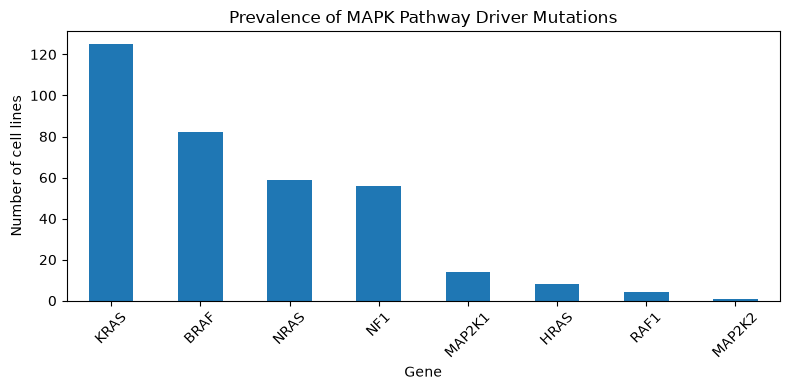

In [37]:
plt.figure(figsize=(8,4))

mapk_prevalence.plot(kind="bar")

plt.ylabel("Number of cell lines")
plt.xlabel("Gene")
plt.title("Prevalence of MAPK Pathway Driver Mutations")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

As Trametinib targets the MAPK signalling pathway, mutations affecting genes within this pathway are of particular biological interest. KRAS was the most frequently mutated MAPK pathway gene, followed by BRAF, NRAS and NF1. The presence of recurrent alterations in these genes supports their investigation as potential predictors of Trametinib sensitivity.

In [38]:
# Identify cell lines with a KRAS mutation
kras_models = set(
    trametinib_mutations.loc[
        trametinib_mutations["gene_symbol"] == "KRAS",
        "model_id"
    ]
)

In [39]:
trametinib_matched["KRAS_status"] = np.where(
    trametinib_matched["SANGER_MODEL_ID"].isin(kras_models),
    "Mutant",
    "Wild type"
)

In [40]:
trametinib_matched["KRAS_status"].value_counts()

KRAS_status
Wild type    823
Mutant       125
Name: count, dtype: int64

<Figure size 500x400 with 0 Axes>

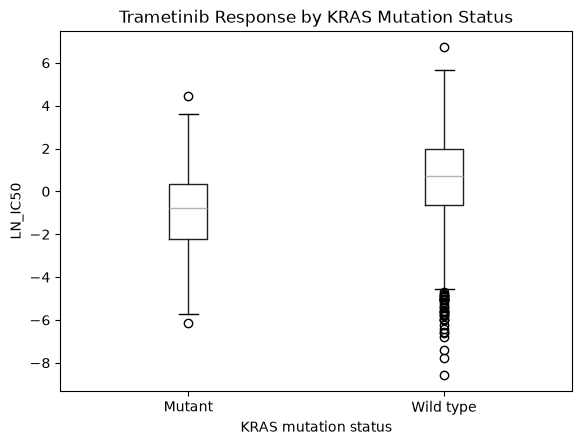

In [41]:
plt.figure(figsize=(5,4))

trametinib_matched.boxplot(
    column="LN_IC50",
    by="KRAS_status",
    grid=False
)

plt.title("Trametinib Response by KRAS Mutation Status")
plt.suptitle("")  # Removes the automatic pandas title
plt.xlabel("KRAS mutation status")
plt.ylabel("LN_IC50")

plt.show()

In [42]:
from scipy.stats import mannwhitneyu

In [43]:

mutant = trametinib_matched.loc[
    trametinib_matched["KRAS_status"] == "Mutant",
    "LN_IC50"
]

wildtype = trametinib_matched.loc[
    trametinib_matched["KRAS_status"] == "Wild type",
    "LN_IC50"
]

stat, p = mannwhitneyu(mutant, wildtype, alternative="two-sided")

print(f"U statistic: {stat:.0f}")
print(f"P-value: {p:.4g}")

U statistic: 32197
P-value: 1.526e-11


KRAS-mutant cell lines exhibited a lower median LN_IC50 than KRAS wild-type cell lines, suggesting greater sensitivity to Trametinib. A Mann–Whitney U test confirmed that the difference in LN_IC50 distributions between the two groups was statistically significant (U = 32,197, p = 1.526 × 10⁻¹¹). Despite this association, substantial variability remained within the wild-type group, indicating that additional genomic or biological factors are likely to contribute to Trametinib response.

In [44]:
# Identify cell lines with a BRAF mutation
braf_models = set(
    trametinib_mutations.loc[
        trametinib_mutations["gene_symbol"] == "BRAF",
        "model_id"
    ]
)

In [45]:
trametinib_matched["BRAF_status"] = np.where(
    trametinib_matched["SANGER_MODEL_ID"].isin(braf_models),
    "Mutant",
    "Wild type"
)

In [46]:
trametinib_matched["BRAF_status"].value_counts()

BRAF_status
Wild type    866
Mutant        82
Name: count, dtype: int64

<Figure size 600x500 with 0 Axes>

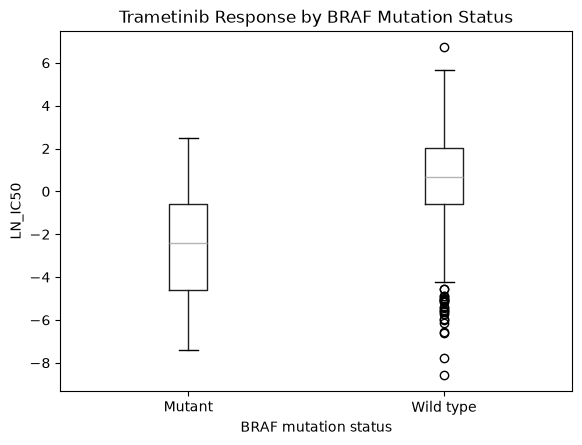

In [47]:
plt.figure(figsize=(6,5))

trametinib_matched.boxplot(
    column="LN_IC50",
    by="BRAF_status",
    grid=False
)

plt.title("Trametinib Response by BRAF Mutation Status")
plt.suptitle("")
plt.xlabel("BRAF mutation status")
plt.ylabel("LN_IC50")

plt.show()

In [48]:
mutant = trametinib_matched.loc[
    trametinib_matched["BRAF_status"] == "Mutant",
    "LN_IC50"
]

wildtype = trametinib_matched.loc[
    trametinib_matched["BRAF_status"] == "Wild type",
    "LN_IC50"
]

stat, p = mannwhitneyu(
    mutant,
    wildtype,
    alternative="two-sided"
)

print(f"U statistic: {stat:.0f}")
print(f"P-value: {p:.4g}")

U statistic: 12267
P-value: 1.059e-22


To further investigate the relationship between MAPK pathway mutations and Trametinib response, LN_IC50 values were compared between BRAF-mutant and BRAF wild-type cell lines. BRAF-mutant cell lines demonstrated a lower median LN_IC50 than wild-type cell lines, indicating greater sensitivity to Trametinib. A Mann–Whitney U test confirmed that the difference in LN_IC50 distributions between the two groups was highly statistically significant (U = 12,267, p = 1.059 × 10⁻²²). These findings are consistent with the known role of BRAF in activating the MAPK signalling pathway and further support the inclusion of MAPK pathway mutations as candidate predictive features for downstream machine learning models.

Exploratory analysis demonstrated a statistically significant negative association between MAPK pathway mutation burden and Trametinib LN_IC50 (Pearson r = -0.306, p < 0.001; Spearman ρ = -0.375, p < 0.001), indicating that cell lines with a greater number of MAPK pathway mutations tended to exhibit increased sensitivity to Trametinib

Exploratory analysis demonstrated substantial variability in Trametinib response across cancer cell lines, supporting the use of LN_IC50 as a continuous response variable for predictive modelling. The matched cohort represented a broad range of tumour types and contained recurrent mutations in several established cancer driver genes, including TP53, KRAS, PIK3CA and BRAF. Analysis of the MAPK signalling pathway confirmed that biologically relevant mutations were well represented within the dataset. Furthermore, both KRAS-mutant and BRAF-mutant cell lines exhibited significantly lower LN_IC50 values than their respective wild-type counterparts (Mann–Whitney U = 32,197, p = 1.526 × 10⁻¹¹; Mann–Whitney U = 12,267, p = 1.059 × 10⁻²²), suggesting increased sensitivity to Trametinib in tumours with activation of the MAPK pathway. Despite these associations, considerable variability remained within the wild-type populations, indicating that additional genomic alterations are also likely to influence drug response. Overall, these findings demonstrate that the matched dataset is biologically relevant, of high quality, and provides a strong foundation for downstream feature engineering and machine learning models aimed at predicting Trametinib sensitivity.

Next Steps

The current notebook established a validated and biologically relevant dataset linking cancer driver mutations with Trametinib response. The next stage of the project will transform the long-format mutation data into a machine-learning-ready feature matrix, engineer genomic predictor variables, and evaluate supervised machine learning models for predicting Trametinib sensitivity.